In [12]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np
import seaborn as sns
import optuna
import shap
import joblib
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             roc_auc_score, roc_curve, f1_score,recall_score,
                             confusion_matrix,precision_score, ConfusionMatrixDisplay)

In [2]:
# 1. Cargar el dataset (el delimitador es punto y coma según la estructura de tu web scraping)
df = pd.read_csv('BD/bd_liga1_Peru_entrenamiento.csv', sep=';')

# 2. Definir las estadísticas base
# No incluimos Pases en el ultimo tercio por contener 445 partidos en blanco
columnas_estadisticas = [
    'goles', 'Posesión de pelota', 'Goles esperados (xG)', 'Tiros totales', 
    'Tiros a puerta', 'Disparos al palo', 'Tiros fuera', 'Tiros bloqueados', 
    'Tiros adentro del area', 'Tiros desde fuera del area', 'Fueras de juego', 
    'Pases', 'Pases precisos', 'Saques de banda', 'Pases al ultimo tercio', 
    'Entradas', 'Intercepciones', 'Recuperaciones', 'Despejes', 'Corners', 'Faltas',
    'Tiros libres', 'Tarjetas amarillas', 'Tarjetas rojas', 'Atajadas', 'Saques de meta'
]

# 3. Desdoblar los datos para los equipos LOCALES
df_local = df[['fecha', 'equipo_local', 'equipo_visitante']].copy()
df_local.columns = ['Fecha', 'Equipo', 'Rival']
df_local['Local'] = 1  # Variable situacional: 1 significa que jugó en casa

for col in columnas_estadisticas:
    df_local[col] = df[f'{col}_local']

# 4. Desdoblar los datos para los equipos VISITANTES
df_visitante = df[['fecha', 'equipo_visitante', 'equipo_local']].copy()
df_visitante.columns = ['Fecha', 'Equipo', 'Rival']
df_visitante['Local'] = 0  # Variable situacional: 0 significa que jugó de visita

for col in columnas_estadisticas:
    df_visitante[col] = df[f'{col}_visitante']

# 5. Unir ambos sub-conjuntos en un solo dataset (formato vertical/pivotado)
df_estructurado = pd.concat([df_local, df_visitante], ignore_index=True)

# 6. Convertir la fecha a formato de tiempo real y ordenar cronológicamente por equipo
df_estructurado['Fecha'] = pd.to_datetime(df_estructurado['Fecha'], format='%d/%m/%Y')
df_estructurado = df_estructurado.sort_values(by=['Equipo', 'Fecha']).reset_index(drop=True)

# 7. Crear el Target
# ── CONFIGURACIÓN — cambiar aquí para entrenar cada modelo ───────────────
TARGET_CONFIG = {
    'goles':    {'columna': 'goles',                  'umbral': 2,   'operador': '>='},
    'tiros':    {'columna': 'Tiros a puerta',          'umbral': 5,   'operador': '>='},
    'xg':       {'columna': 'Goles esperados (xG)',    'umbral': 1.5, 'operador': '>='},
}

MODELO_ACTIVO = 'goles'   # ← solo cambias esto: 'goles', 'tiros' o 'xg'

cfg = TARGET_CONFIG[MODELO_ACTIVO]
condicion_target = df_estructurado[cfg['columna']] >= cfg['umbral']
df_estructurado['Target'] = np.where(condicion_target, 1, 0)

print(f"Modelo activo: {cfg['columna']} >= {cfg['umbral']}")

# Verificar el resultado final
print("Dimensiones del nuevo dataset:", df_estructurado.shape)
print("\nMuestra de las variables clave calculadas:")
print(df_estructurado[['Fecha', 'Equipo', 'Rival', 'Local', 'Goles esperados (xG)', 'Tiros a puerta', 'goles', 'Target']].head(5))

Modelo activo: goles >= 2
Dimensiones del nuevo dataset: (2156, 31)

Muestra de las variables clave calculadas:
       Fecha             Equipo           Rival  Local  Goles esperados (xG)  \
0 2025-02-09  ADC Juan Pablo II      Sport Boys      0                  1.21   
1 2025-02-16  ADC Juan Pablo II  Sport Huancayo      1                  0.55   
2 2025-02-21  ADC Juan Pablo II    Alianza Lima      0                  1.13   
3 2025-03-10  ADC Juan Pablo II      Binacional      0                  0.45   
4 2025-03-30  ADC Juan Pablo II             UTC      1                  3.56   

   Tiros a puerta  goles  Target  
0               1      0       0  
1               1      0       0  
2               4      0       0  
3               2      0       0  
4               6      4       1  


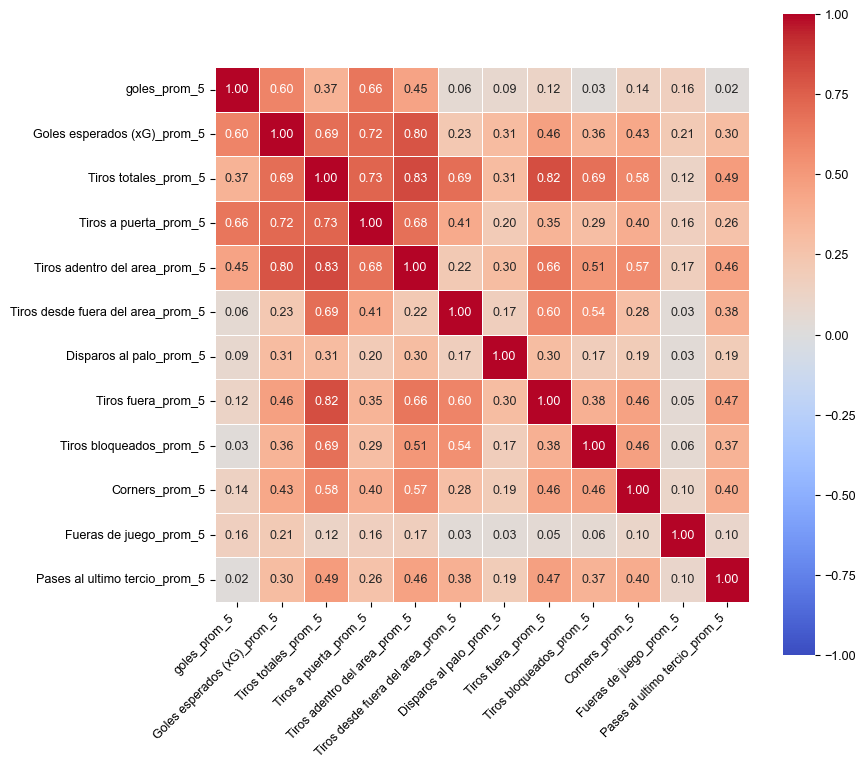

FASE A — Pares > 0.85 — Variables Ofensivas
  Ningún par supera el umbral crítico


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE 2 — Ingeniería de características y ventanas móviles (4.1.5)
# ══════════════════════════════════════════════════════════════════════════════
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Calibri', 'DejaVu Sans'],
    'font.size': 9,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

# ══════════════════════════════════════════════════════════════════════════════
# FASE A — Análisis de correlación — Variables Ofensivas
# ══════════════════════════════════════════════════════════════════════════════

# Variables ofensivas seleccionadas por dominio táctico
vars_ofensivas = [
    'goles', 'Goles esperados (xG)', 'Tiros totales',
    'Tiros a puerta', 'Tiros adentro del area',
    'Tiros desde fuera del area', 'Disparos al palo',
    'Tiros fuera', 'Tiros bloqueados',
    'Corners', 'Fueras de juego', 'Pases al ultimo tercio'
]

# Rolling de 5 partidos solo con variables ofensivas
df_diag = df_estructurado.copy()
for col in vars_ofensivas:
    df_diag[f'{col}_prom_5'] = df_diag.groupby('Equipo')[col].transform(
        lambda x: x.shift(1).rolling(window=5, min_periods=1).mean()
    )

df_diag = df_diag.dropna().reset_index(drop=True)
features_of = [f'{col}_prom_5' for col in vars_ofensivas]
X_of = df_diag[features_of]

# Matriz de correlación — Variables Ofensivas
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(
    X_of.corr(),
    annot=True,
    fmt='.2f',
    annot_kws={'size': 9},
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    vmin=-1, vmax=1,
    ax=ax
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('matriz_correlacion_ofensivas.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

# Pares problemáticos > 0.85
corr_of  = X_of.corr().abs()
pares_of = (
    corr_of
    .where((corr_of > 0.85) & (corr_of < 1.0))
    .stack().reset_index()
)
pares_of.columns = ['Variable 1', 'Variable 2', 'Correlación']
pares_of = pares_of.drop_duplicates(
    subset=['Correlación']
).sort_values('Correlación', ascending=False).dropna()

print("=" * 60)
print("FASE A — Pares > 0.85 — Variables Ofensivas")
print("=" * 60)
if pares_of.empty:
    print("  Ningún par supera el umbral crítico")
else:
    print(pares_of.to_string())

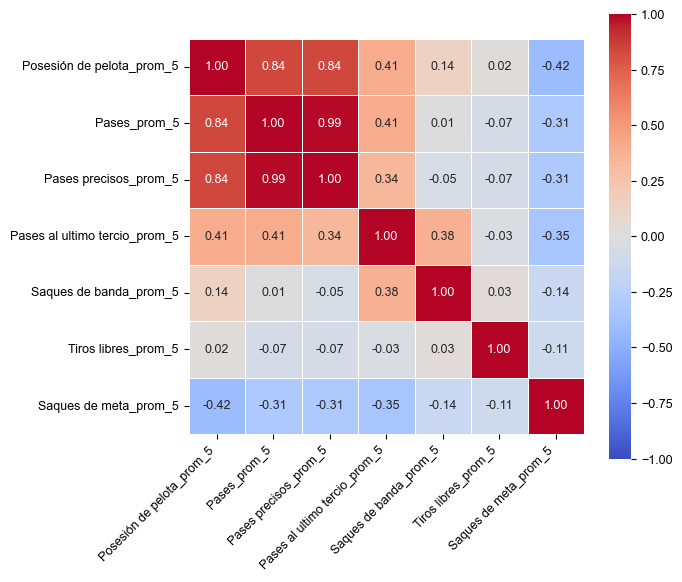

FASE A.2 — Pares > 0.85 — Variables de Posesión y Construcción
     Variable 1             Variable 2  Correlación
9  Pases_prom_5  Pases precisos_prom_5     0.990203


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# FASE A.2 — Análisis de correlación — Variables de Posesión y Construcción
# ══════════════════════════════════════════════════════════════════════════════

vars_posesion = [
    'Posesión de pelota', 'Pases', 'Pases precisos',
    'Pases al ultimo tercio', 'Saques de banda',
    'Tiros libres', 'Saques de meta'
]

df_diag2 = df_estructurado.copy()
for col in vars_posesion:
    df_diag2[f'{col}_prom_5'] = df_diag2.groupby('Equipo')[col].transform(
        lambda x: x.shift(1).rolling(window=5, min_periods=1).mean()
    )

df_diag2 = df_diag2.dropna().reset_index(drop=True)
features_pos = [f'{col}_prom_5' for col in vars_posesion]
X_pos = df_diag2[features_pos]

# Matriz de correlación — Variables de Posesión y Construcción de Juego
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    X_pos.corr(),
    annot=True,
    fmt='.2f',
    annot_kws={'size': 9},
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    vmin=-1, vmax=1,
    ax=ax
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('matriz_correlacion_posesion.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

# Pares problemáticos > 0.85
corr_pos  = X_pos.corr().abs()
pares_pos = (
    corr_pos
    .where((corr_pos > 0.85) & (corr_pos < 1.0))
    .stack().reset_index()
)
pares_pos.columns = ['Variable 1', 'Variable 2', 'Correlación']
pares_pos = pares_pos.drop_duplicates(
    subset=['Correlación']
).sort_values('Correlación', ascending=False).dropna()

print("=" * 60)
print("FASE A.2 — Pares > 0.85 — Variables de Posesión y Construcción")
print("=" * 60)
if pares_pos.empty:
    print("  Ningún par supera el umbral crítico")
else:
    print(pares_pos.to_string())


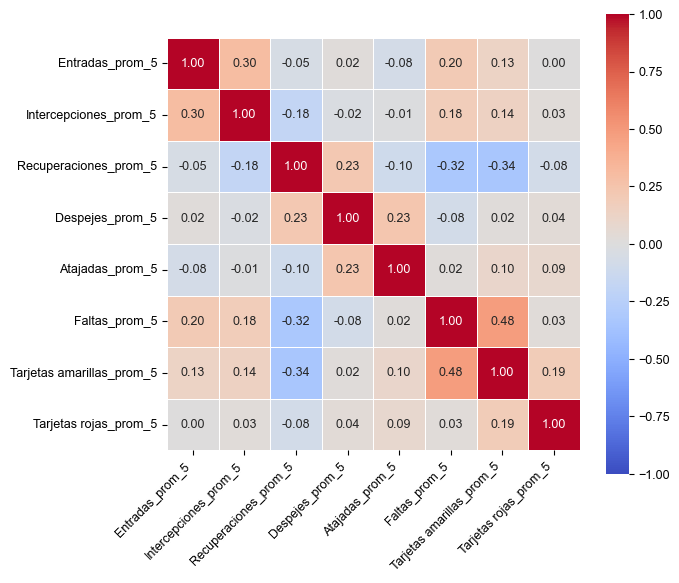

FASE A.3 — Pares > 0.85 — Variables Defensivas y de Disciplina
  Ningún par supera el umbral crítico


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# FASE A.3 — Análisis de correlación — Variables Defensivas y de Disciplina
# ══════════════════════════════════════════════════════════════════════════════

vars_defensivas = [
    'Entradas', 'Intercepciones', 'Recuperaciones', 'Despejes',
    'Atajadas', 'Faltas', 'Tarjetas amarillas', 'Tarjetas rojas'
]

df_diag3 = df_estructurado.copy()
for col in vars_defensivas:
    df_diag3[f'{col}_prom_5'] = df_diag3.groupby('Equipo')[col].transform(
        lambda x: x.shift(1).rolling(window=5, min_periods=1).mean()
    )

df_diag3 = df_diag3.dropna().reset_index(drop=True)
features_def = [f'{col}_prom_5' for col in vars_defensivas]
X_def = df_diag3[features_def]

# Matriz de correlación — Variables Defensivas y de Disciplina
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    X_def.corr(),
    annot=True,
    fmt='.2f',
    annot_kws={'size': 9},
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    vmin=-1, vmax=1,
    ax=ax
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('matriz_correlacion_defensivas.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

# Pares problemáticos > 0.85
corr_def  = X_def.corr().abs()
pares_def = (
    corr_def
    .where((corr_def > 0.85) & (corr_def < 1.0))
    .stack().reset_index()
)
pares_def.columns = ['Variable 1', 'Variable 2', 'Correlación']
pares_def = pares_def.drop_duplicates(
    subset=['Correlación']
).sort_values('Correlación', ascending=False).dropna()

print("=" * 60)
print("FASE A.3 — Pares > 0.85 — Variables Defensivas y de Disciplina")
print("=" * 60)
if pares_def.empty:
    print("  Ningún par supera el umbral crítico")
else:
    print(pares_def.to_string())


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# FASE B — Crear ratios de eficiencia
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("FASE B — Creación de ratios de eficiencia")
print("=" * 60)

# precision_pases → resuelve Pases/Pases precisos (r=0.99015)
df_estructurado['precision_pases'] = (
    df_estructurado['Pases precisos'] /
    df_estructurado['Pases'].replace(0, np.nan)
)
# precision_tiros → información más densa que Tiros totales
df_estructurado['precision_tiros'] = (
    df_estructurado['Tiros a puerta'] /
    df_estructurado['Tiros totales'].replace(0, np.nan)
)
# conversion_xg → eficacia goleadora vs calidad de oportunidades
df_estructurado['conversion_xg'] = (
    df_estructurado['goles'] /
    df_estructurado['Goles esperados (xG)'].replace(0, np.nan)
)
# ratio_area → calidad posicional del ataque
df_estructurado['ratio_area'] = (
    df_estructurado['Tiros adentro del area'] /
    df_estructurado['Tiros totales'].replace(0, np.nan)
)

print("Estadísticas de los ratios creados:")
print(df_estructurado[['precision_pases', 'precision_tiros',
                        'conversion_xg', 'ratio_area']].describe().round(3))

# Lista completa para rolling
# Excluidos de originales: Pases, Pases precisos (r=0.99 → reemplazados por precision_pases)
cols_para_rolling = [
    'goles', 'Posesión de pelota', 'Goles esperados (xG)', 'Tiros totales',
    'Tiros a puerta', 
    'Disparos al palo', 
    'Tiros fuera', 'Tiros bloqueados',
    'Tiros adentro del area', 'Tiros desde fuera del area', 'Fueras de juego',
    'Saques de banda', 'Pases al ultimo tercio',
    'Entradas', 'Intercepciones', 'Recuperaciones', 'Despejes', 'Corners', 'Faltas',
    'Tiros libres', 'Tarjetas amarillas', 'Tarjetas rojas', 'Atajadas', 'Saques de meta',
    'precision_pases', 'precision_tiros', 'conversion_xg', 'ratio_area'
]

print(f"\nTotal variables para rolling: {len(cols_para_rolling)}")

# ══════════════════════════════════════════════════════════════════════════════
# FASE C — Ventanas móviles combinadas 3+5
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("FASE C — Cálculo de ventanas móviles combinadas 3+5")
print("=" * 60)

df_combo = df_estructurado.copy()

for col in cols_para_rolling:
    # Ventana 3 — momentum inmediato
    df_combo[f'{col}_prom_3'] = df_combo.groupby('Equipo')[col].transform(
        lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
    )
    # Ventana 5 — tendencia reciente
    df_combo[f'{col}_prom_5'] = df_combo.groupby('Equipo')[col].transform(
        lambda x: x.shift(1).rolling(window=5, min_periods=1).mean()
    )

df_modelado_completo = df_combo.dropna().reset_index(drop=True)

print(f"  Observaciones: {len(df_modelado_completo)}")
print(f"  Columnas totales: {df_modelado_completo.shape[1]}")


FASE B — Creación de ratios de eficiencia
Estadísticas de los ratios creados:
       precision_pases  precision_tiros  conversion_xg  ratio_area
count         2152.000         2155.000       2149.000    2155.000
mean             0.768            0.341          1.047       0.562
std              0.078            0.159          1.117       0.177
min              0.456            0.000          0.000       0.000
25%              0.725            0.231          0.000       0.444
50%              0.777            0.333          0.893       0.571
75%              0.824            0.438          1.493       0.688
max              0.944            1.000         16.667       1.000

Total variables para rolling: 28

FASE C — Cálculo de ventanas móviles combinadas 3+5
  Observaciones: 2123
  Columnas totales: 91


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# FASE D — Verificación de multicolinealidad post-ratios
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("FASE D — Verificación de correlación con ratios (ventana 5)")
print("=" * 60)

features_5_ratios = [f'{col}_prom_5' for col in cols_para_rolling] + ['Local']
X_5_ratios = df_modelado_completo[features_5_ratios]

corr_abs_r = X_5_ratios.corr().abs()
pares_ratios = (
    corr_abs_r
    .where((corr_abs_r > 0.85) & (corr_abs_r < 1.0))
    .stack().reset_index()
)
pares_ratios.columns = ['Variable 1', 'Variable 2', 'Correlación']
pares_ratios = pares_ratios.drop_duplicates(
    subset=['Correlación']
).sort_values('Correlación', ascending=False).dropna()

print(f"\nTotal variables analizadas : {len(features_5_ratios)}")
print(f"Pares con correlación > 0.85: {len(pares_ratios)}\n")

if pares_ratios.empty:
    print("  ✓ Ningún par supera el umbral crítico — multicolinealidad resuelta")
else:
    print(pares_ratios.to_string(index=False))

# ══════════════════════════════════════════════════════════════════════════════
# FASE E — Dataset final para el modelo
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("FASE E — Dataset final")
print("=" * 60)

cols_modelo_final = cols_para_rolling

features_final = (
    [f'{col}_prom_3' for col in cols_modelo_final] +
    [f'{col}_prom_5' for col in cols_modelo_final] +
    ['Local']
)

X = df_modelado_completo[features_final]
y = df_modelado_completo['Target']

print(f"  Observaciones:    {len(df_modelado_completo)}")
print(f"  Features finales: {len(features_final)}")
print(f"  Nulos en X:       {X.isnull().sum().sum()}")
print(f"\nDistribución del Target:")
print(y.value_counts().to_string())
print(f"\nFeatures finales ({len(features_final)}):")
for i, f in enumerate(features_final, 1):
    print(f"  {i:2}. {f}")

print("\n✅ BLOQUE 2 completado — X e y listos para el Bloque 3")


FASE D — Verificación de correlación con ratios (ventana 5)

Total variables analizadas : 29
Pares con correlación > 0.85: 0

  ✓ Ningún par supera el umbral crítico — multicolinealidad resuelta

FASE E — Dataset final
  Observaciones:    2123
  Features finales: 57
  Nulos en X:       0

Distribución del Target:
Target
0    1335
1     788

Features finales (57):
   1. goles_prom_3
   2. Posesión de pelota_prom_3
   3. Goles esperados (xG)_prom_3
   4. Tiros totales_prom_3
   5. Tiros a puerta_prom_3
   6. Disparos al palo_prom_3
   7. Tiros fuera_prom_3
   8. Tiros bloqueados_prom_3
   9. Tiros adentro del area_prom_3
  10. Tiros desde fuera del area_prom_3
  11. Fueras de juego_prom_3
  12. Saques de banda_prom_3
  13. Pases al ultimo tercio_prom_3
  14. Entradas_prom_3
  15. Intercepciones_prom_3
  16. Recuperaciones_prom_3
  17. Despejes_prom_3
  18. Corners_prom_3
  19. Faltas_prom_3
  20. Tiros libres_prom_3
  21. Tarjetas amarillas_prom_3
  22. Tarjetas rojas_prom_3
  23. Ataja

<table width='90%'>

<tr>
<td bgcolor='#fcce4f'>

## **<font color="#000000"> MODELOS CON LOS PARAMETROS YA OPTIMIZADOS</font>**
</td>
</tr>
</table>

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE 3 — Entrenamiento, optimización y validación del modelo XGBoost
# ══════════════════════════════════════════════════════════════════════════════
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Calibri', 'DejaVu Sans'],
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

# IMPORTANTE: X e y vienen directamente del Bloque 2 — no recalcular
print("=" * 60)
print("DATASET FINAL — recibido del Bloque 2")
print("=" * 60)
print(f"Observaciones totales: {len(df_modelado_completo)}")
print(f"Total features:        {len(features_final)}")
print(f"Nulos en X:            {X.isnull().sum().sum()}")
print(f"\nDistribución del Target:")
print(y.value_counts().to_string())

# ── 4.2.1 División temporal 80/20 ─────────────────────────────────────────────
fecha_corte = df_modelado_completo['Fecha'].quantile(0.8)

train_mask = df_modelado_completo['Fecha'] <= fecha_corte
test_mask  = df_modelado_completo['Fecha'] > fecha_corte

X_train = X[train_mask]
X_test  = X[test_mask]
y_train = y[train_mask]
y_test  = y[test_mask]

print("\n" + "=" * 60)
print("4.2.1 DIVISIÓN TEMPORAL DEL DATASET")
print("=" * 60)
print(f"Fecha de corte:     {fecha_corte.date()}")
print(f"Train — desde:      {df_modelado_completo[train_mask]['Fecha'].min().date()}")
print(f"Train — hasta:      {df_modelado_completo[train_mask]['Fecha'].max().date()}")
print(f"Train — partidos:   {len(X_train)}")
print(f"Test  — desde:      {df_modelado_completo[test_mask]['Fecha'].min().date()}")
print(f"Test  — hasta:      {df_modelado_completo[test_mask]['Fecha'].max().date()}")
print(f"Test  — partidos:   {len(X_test)}")

# ── 4.2.2 Balanceo de clases con SMOTE solo en train ─────────────────────────
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\n" + "=" * 60)
print("4.2.2 BALANCEO DE CLASES CON SMOTE")
print("=" * 60)
print("Train ANTES de SMOTE:")
print(y_train.value_counts().to_string())
print("\nTrain DESPUÉS de SMOTE (balanceado):")
print(y_train_res.value_counts().to_string())
print("\nTest — intacto (desbalance real del fútbol):")
print(y_test.value_counts().to_string())


DATASET FINAL — recibido del Bloque 2
Observaciones totales: 2123
Total features:        57
Nulos en X:            0

Distribución del Target:
Target
0    1335
1     788

4.2.1 DIVISIÓN TEMPORAL DEL DATASET
Fecha de corte:     2025-08-23
Train — desde:      2023-02-11
Train — hasta:      2025-08-23
Train — partidos:   1701
Test  — desde:      2025-08-24
Test  — hasta:      2026-04-27
Test  — partidos:   422

4.2.2 BALANCEO DE CLASES CON SMOTE
Train ANTES de SMOTE:
Target
0    1080
1     621

Train DESPUÉS de SMOTE (balanceado):
Target
0    1080
1    1080

Test — intacto (desbalance real del fútbol):
Target
0    255
1    167


In [9]:
# ── 4.2.3 Optimización de hiperparámetros — Cargar configuración óptima ────────
import json
print("\n" + "=" * 60)
print("4.2.3 CONFIGURACIÓN ÓPTIMA DE HIPERPARÁMETROS")
print("=" * 60)

# Cargar hiperparámetros óptimos previamente encontrados
# Resultado de la búsqueda bayesiana con rangos afinados y 200 trials
with open('Hiperparametros_Finales/Goles/hiperparametros_optimos_goles.json', 'r') as f:
    best_params = json.load(f)

best_params['verbosity'] = 0

print("Hiperparámetros óptimos cargados:")
for k, v in best_params.items():
    if k not in ['random_state', 'eval_metric', 'verbosity']:
        print(f"  {k:<25} = {round(v, 6) if isinstance(v, float) else v}")

# ── 4.2.4 Entrenamiento final ─────────────────────────────────────────────────
print("\n" + "=" * 60)
print("4.2.4 ENTRENAMIENTO DEL MODELO FINAL")
print("=" * 60)

xgb_final_model = XGBClassifier(**best_params)
xgb_final_model.fit(X_train_res, y_train_res)
print("Modelo entrenado exitosamente.")

# ── 4.4 Métricas de validación ────────────────────────────────────────────────
y_pred = xgb_final_model.predict(X_test)
y_prob = xgb_final_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
auc      = roc_auc_score(y_test, y_prob)
f1       = f1_score(y_test, y_pred)

print("\n" + "=" * 60)
print("4.4 MÉTRICAS DE VALIDACIÓN")
print("=" * 60)
print(f"Accuracy:   {accuracy * 100:.2f}%")
print(f"AUC-ROC:    {auc:.4f}")
print(f"F1-Score:   {f1:.4f}")
print("\nReporte detallado:")
print(classification_report(
    y_test, y_pred,
    target_names=['Rendimiento Deficiente (0)',
                  'Alto Rendimiento Ofensivo (1)']
))


4.2.3 CONFIGURACIÓN ÓPTIMA DE HIPERPARÁMETROS
Hiperparámetros óptimos cargados:
  n_estimators              = 199
  max_depth                 = 6
  learning_rate             = 0.013394
  subsample                 = 0.852376
  colsample_bytree          = 0.918167
  min_child_weight          = 3
  gamma                     = 0.859217

4.2.4 ENTRENAMIENTO DEL MODELO FINAL
Modelo entrenado exitosamente.

4.4 MÉTRICAS DE VALIDACIÓN
Accuracy:   62.09%
AUC-ROC:    0.5688
F1-Score:   0.3750

Reporte detallado:
                               precision    recall  f1-score   support

   Rendimiento Deficiente (0)       0.64      0.84      0.73       255
Alto Rendimiento Ofensivo (1)       0.54      0.29      0.38       167

                     accuracy                           0.62       422
                    macro avg       0.59      0.56      0.55       422
                 weighted avg       0.60      0.62      0.59       422



In [10]:
# ── Guardar modelo y hiperparámetros ──────────────────────────────────────────
import joblib
import json

joblib.dump(xgb_final_model, 'modelo_xgboost_liga1_goles.pkl')

hiperparametros_guardar = {
    k: v for k, v in best_params.items()
    if k not in ['verbosity']
}
with open('hiperparametros_optimos.json', 'w') as f:
    json.dump(hiperparametros_guardar, f, indent=4)

print("\n✅ Modelo guardado: modelo_xgboost_liga1.pkl")
print("✅ Hiperparámetros guardados: hiperparametros_optimos.json")


✅ Modelo guardado: modelo_xgboost_liga1.pkl
✅ Hiperparámetros guardados: hiperparametros_optimos.json


<table width='90%'>

<tr>
<td bgcolor='#FFBA39'>

## **<font color="#000000"> LightGBM con optimización Optuna</font>**
</td>
</tr>
</table>

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# LightGBM con optimización Optuna
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("BLOQUE 4 — LightGBM")
print("=" * 60)

lgbm_final = joblib.load('Hiperparametros_Finales/Goles/modelo_lightgbm_liga1_goles.pkl')
print("Modelo cargado exitosamente desde 'modelo_lightgbm_liga1_goles.pkl'")

y_pred_lgbm = lgbm_final.predict(X_test)
y_prob_lgbm = lgbm_final.predict_proba(X_test)[:, 1]

# ── Métricas ───────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("MÉTRICAS — LightGBM")
print("=" * 60)
print(f"Accuracy:   {accuracy_score(y_test, y_pred_lgbm)*100:.2f}%")
print(f"AUC-ROC:    {roc_auc_score(y_test, y_prob_lgbm):.4f}")
print(f"F1-Score:   {f1_score(y_test, y_pred_lgbm):.4f}")
print(f"Precision:  {precision_score(y_test, y_pred_lgbm):.4f}")

print("\nReporte detallado:")
print(classification_report(
    y_test, y_pred_lgbm,
    target_names=['Rendimiento Deficiente (0)', 'Alto Rendimiento Ofensivo (1)']
))


BLOQUE 4 — LightGBM
Modelo cargado exitosamente desde 'modelo_lightgbm_liga1_goles.pkl'

MÉTRICAS — LightGBM
Accuracy:   61.14%
AUC-ROC:    0.5625
F1-Score:   0.3835
Precision:  0.5152

Reporte detallado:
                               precision    recall  f1-score   support

   Rendimiento Deficiente (0)       0.64      0.81      0.72       255
Alto Rendimiento Ofensivo (1)       0.52      0.31      0.38       167

                     accuracy                           0.61       422
                    macro avg       0.58      0.56      0.55       422
                 weighted avg       0.59      0.61      0.58       422



In [12]:
joblib.dump(lgbm_final, 'modelo_lightgbm_liga1_goles.pkl')
print("✅ Modelo guardado: modelo_lightgbm_liga1_goles.pkl")

✅ Modelo guardado: modelo_lightgbm_liga1_goles.pkl


<table width='90%'>

<tr>
<td bgcolor='#FFBA39'>

## **<font color="#000000"> Random Forest con optimización Optuna</font>**
</td>
</tr>
</table>

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# Random Forest — carga desde modelo guardado
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("BLOQUE 5 — Random Forest")
print("=" * 60)

rf_final = joblib.load('Hiperparametros_Finales/Goles/modelo_randomforest_liga1_goles.pkl')
print("Modelo cargado exitosamente desde 'modelo_randomforest_liga1_goles.pkl'")

y_pred_rf = rf_final.predict(X_test)
y_prob_rf  = rf_final.predict_proba(X_test)[:, 1]

# ── Métricas ───────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("MÉTRICAS — Random Forest")
print("=" * 60)
print(f"Accuracy:   {accuracy_score(y_test, y_pred_rf)*100:.2f}%")
print(f"AUC-ROC:    {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"F1-Score:   {f1_score(y_test, y_pred_rf):.4f}")
print(f"Precision:  {precision_score(y_test, y_pred_rf):.4f}")

print("\nReporte detallado:")
print(classification_report(
    y_test, y_pred_rf,
    target_names=['Rendimiento Deficiente (0)', 'Alto Rendimiento Ofensivo (1)']
))


BLOQUE 5 — Random Forest
Modelo cargado exitosamente desde 'modelo_randomforest_liga1_goles.pkl'

MÉTRICAS — Random Forest
Accuracy:   57.11%
AUC-ROC:    0.5694
F1-Score:   0.4930
Precision:  0.4632

Reporte detallado:
                               precision    recall  f1-score   support

   Rendimiento Deficiente (0)       0.66      0.60      0.63       255
Alto Rendimiento Ofensivo (1)       0.46      0.53      0.49       167

                     accuracy                           0.57       422
                    macro avg       0.56      0.56      0.56       422
                 weighted avg       0.58      0.57      0.57       422



In [14]:
joblib.dump(rf_final, 'modelo_randomforest_liga1_goles.pkl')
print("✅ Modelo guardado: modelo_randomforest_liga1.pkl")

✅ Modelo guardado: modelo_randomforest_liga1.pkl


<table width='90%'>

<tr>
<td bgcolor='#FFBA39'>

## **<font color="#000000"> Logistic Regression con optimización Optuna</font>**
</td>
</tr>
</table>

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# Logistic Regression — carga desde modelos guardados
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("BLOQUE 5B — Logistic Regression")
print("=" * 60)

scaler   = joblib.load('Hiperparametros_Finales/Goles/scaler_logistic_liga1_goles.pkl')
lr_final = joblib.load('Hiperparametros_Finales/Goles/modelo_logistic_liga1_goles.pkl')
print("Modelo cargado exitosamente desde 'modelo_logistic_liga1_goles.pkl'")
print("Scaler cargado exitosamente desde 'scaler_logistic_liga1_goles.pkl'")

X_test_scaled = scaler.transform(X_test)

y_pred_lr = lr_final.predict(X_test_scaled)
y_prob_lr = lr_final.predict_proba(X_test_scaled)[:, 1]

# ── Métricas ───────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("MÉTRICAS — Logistic Regression")
print("=" * 60)
print(f"Accuracy:   {accuracy_score(y_test, y_pred_lr)*100:.2f}%")
print(f"AUC-ROC:    {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"F1-Score:   {f1_score(y_test, y_pred_lr):.4f}")
print(f"Precision:  {precision_score(y_test, y_pred_lr):.4f}")

print("\nReporte detallado:")
print(classification_report(
    y_test, y_pred_lr,
    target_names=['Rendimiento Deficiente (0)', 'Alto Rendimiento Ofensivo (1)']
))


BLOQUE 5B — Logistic Regression
Modelo cargado exitosamente desde 'modelo_logistic_liga1_goles.pkl'
Scaler cargado exitosamente desde 'scaler_logistic_liga1_goles.pkl'

MÉTRICAS — Logistic Regression
Accuracy:   63.03%
AUC-ROC:    0.6470
F1-Score:   0.5357
Precision:  0.5325

Reporte detallado:
                               precision    recall  f1-score   support

   Rendimiento Deficiente (0)       0.70      0.69      0.69       255
Alto Rendimiento Ofensivo (1)       0.53      0.54      0.54       167

                     accuracy                           0.63       422
                    macro avg       0.61      0.61      0.61       422
                 weighted avg       0.63      0.63      0.63       422



In [16]:
joblib.dump(lr_final,  'modelo_logistic_liga1.pkl')
joblib.dump(scaler,    'scaler_logistic_liga1.pkl')
print("✅ Modelo guardado: modelo_logistic_liga1_goles.pkl")
print("✅ Scaler guardado: scaler_logistic_liga1_goles.pkl")

✅ Modelo guardado: modelo_logistic_liga1_goles.pkl
✅ Scaler guardado: scaler_logistic_liga1_goles.pkl


COMPARACIÓN FINAL — 4 MODELOS
                     Accuracy  AUC-ROC  F1-Score  Precision  Recall
Modelo                                                             
XGBoost                 62.09   0.5688    0.3750     0.5393  0.2874
LightGBM                61.14   0.5625    0.3835     0.5152  0.3054
Random Forest           57.11   0.5694    0.4930     0.4632  0.5269
Logistic Regression     63.03   0.6470    0.5357     0.5325  0.5389

Mejor Accuracy:   Logistic Regression  (63.03%)
Mejor AUC-ROC:    Logistic Regression  (0.647)
Mejor Precision:  XGBoost  (0.5393)
Mejor F1-Score:   Logistic Regression  (0.5357)


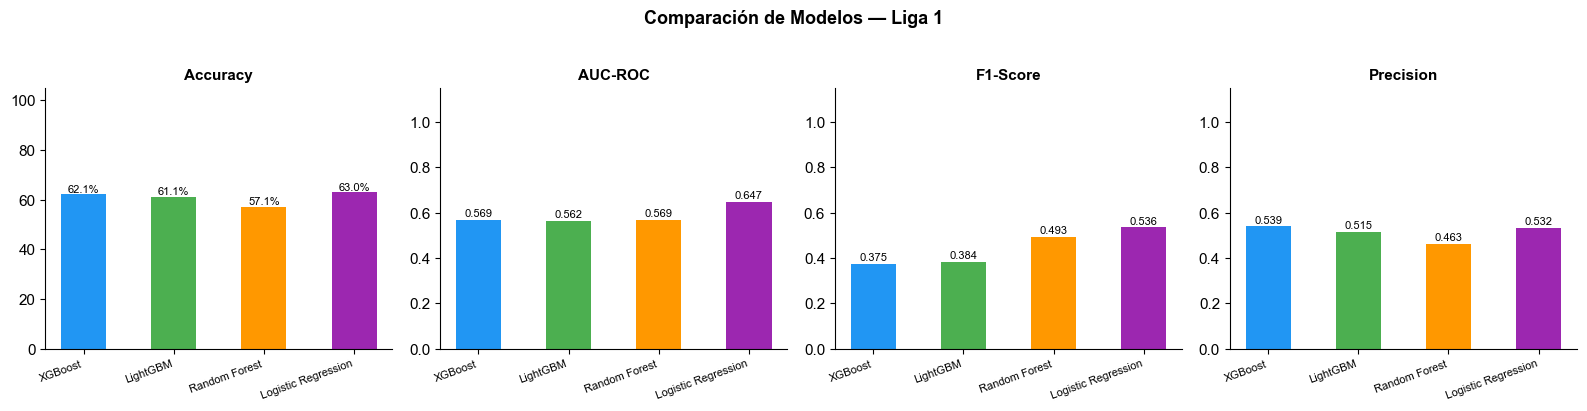

✅ Gráfico guardado: comparacion_modelos.png


In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE 6 — Comparación final de los 4 modelos
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             f1_score, precision_score, recall_score)

modelos = {
    'XGBoost':            (y_pred,  y_prob),
    'LightGBM':           (y_pred_lgbm, y_prob_lgbm),
    'Random Forest':      (y_pred_rf,   y_prob_rf),
    'Logistic Regression':(y_pred_lr,   y_prob_lr),
}

filas = []
for nombre, (pred, prob) in modelos.items():
    filas.append({
        'Modelo':    nombre,
        'Accuracy':  round(accuracy_score(y_test, pred) * 100, 2),
        'AUC-ROC':   round(roc_auc_score(y_test, prob), 4),
        'F1-Score':  round(f1_score(y_test, pred), 4),
        'Precision': round(precision_score(y_test, pred), 4),
        'Recall':    round(recall_score(y_test, pred), 4),
    })

df_comp = pd.DataFrame(filas).set_index('Modelo')

print("=" * 75)
print("COMPARACIÓN FINAL — 4 MODELOS")
print("=" * 75)
print(df_comp.to_string())
print("=" * 75)
print(f"\nMejor Accuracy:   {df_comp['Accuracy'].idxmax()}  ({df_comp['Accuracy'].max()}%)")
print(f"Mejor AUC-ROC:    {df_comp['AUC-ROC'].idxmax()}  ({df_comp['AUC-ROC'].max()})")
print(f"Mejor Precision:  {df_comp['Precision'].idxmax()}  ({df_comp['Precision'].max()})")
print(f"Mejor F1-Score:   {df_comp['F1-Score'].idxmax()}  ({df_comp['F1-Score'].max()})")

# ── Gráfico de barras comparativo ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
metricas = ['Accuracy', 'AUC-ROC', 'F1-Score', 'Precision']
colores  = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for ax, metrica in zip(axes, metricas):
    valores = df_comp[metrica].values
    barras  = ax.bar(range(len(df_comp)), valores, color=colores, width=0.5)
    ax.set_title(metrica, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.15 if metrica != 'Accuracy' else 105)
    ax.set_xticks(range(len(df_comp)))
    ax.set_xticklabels(df_comp.index, rotation=20, ha='right', fontsize=8)
    for bar, val in zip(barras, valores):
        label = f'{val:.1f}%' if metrica == 'Accuracy' else f'{val:.3f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                label, ha='center', va='bottom', fontsize=8)

plt.suptitle('Comparación de Modelos — Liga 1', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Gráfico guardado: comparacion_modelos.png")

In [10]:
# ── Selección de modelo ────────────────────────────────────────────────────────
print("=" * 50)
print("  SELECCIÓN DE MODELO PARA BACKTESTING")
print("=" * 50)
print("  1 — XGBoost")
print("  2 — LightGBM")
print("  3 — Random Forest")
print("  4 — Logistic Regression")
print("=" * 50)

opcion = input("  Ingresa el número del modelo (1-4): ").strip()

modelos_config = {
    '1': ('XGBoost',             'Hiperparametros_Finales/Goles/modelo_xgboost_liga1_goles.pkl',            None),
    '2': ('LightGBM',            'Hiperparametros_Finales/Goles/modelo_lightgbm_liga1_goles.pkl',     None),
    '3': ('Random Forest',       'Hiperparametros_Finales/Goles/modelo_randomforest_liga1_goles.pkl', None),
    '4': ('Logistic Regression', 'Hiperparametros_Finales/Goles/modelo_logistic_liga1_goles.pkl',     'Hiperparametros_Finales/Goles/scaler_logistic_liga1_goles.pkl'),
}

if opcion not in modelos_config:
    raise ValueError(f"Opción inválida: '{opcion}'. Ingresa un número del 1 al 4.")

nombre_modelo, archivo_modelo, archivo_scaler = modelos_config[opcion]
modelo_bt = joblib.load(archivo_modelo)
scaler_bt = joblib.load(archivo_scaler) if archivo_scaler else None
print(f"\n  ✅ Modelo seleccionado: {nombre_modelo}")


  SELECCIÓN DE MODELO PARA BACKTESTING
  1 — XGBoost
  2 — LightGBM
  3 — Random Forest
  4 — Logistic Regression

  ✅ Modelo seleccionado: XGBoost


In [22]:
print("XGBoost:")
print(xgb_final_model.get_params())

print("\nLightGBM:")
print(lgbm_final.get_params())

print("\nRandom Forest:")
print(rf_final.get_params())

print("\nLogistic Regression:")
print(lr_final.get_params())


XGBoost:
{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.9181672848877499, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'logloss', 'feature_types': None, 'feature_weights': None, 'gamma': 0.8592172265027298, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.013394466969388733, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 6, 'max_leaves': None, 'min_child_weight': 3, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 199, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.852375630251445, 'tree_method': None, 'validate_parameters': None, 'verbosity': 0}

LightGBM:
{'boo

In [13]:
# Backtesting: evaluar predicciones en partidos post-corte
# Usa el modelo ya entrenado y compara contra resultados reales
# Requiere: xgb_final_model, features_final, cols_modelo_final, columnas_estadisticas

FECHA_CORTE = pd.Timestamp('2026-04-27')

# 1. Cargar dataset completo SIN filtro de fecha
df_bt = pd.read_csv('BD/bd_liga1_apertura_ronda_17.csv', sep=';')
df_bt['fecha'] = pd.to_datetime(df_bt['fecha'], format='%d/%m/%Y')
print('Partidos en CSV:', len(df_bt))
print('Rango:', df_bt['fecha'].min().date(), '->', df_bt['fecha'].max().date())

# 2. Reestructurar igual que Bloque 1
df_bt['fecha'] = df_bt['fecha'].dt.strftime('%d/%m/%Y')

df_local_bt = df_bt[['fecha', 'equipo_local', 'equipo_visitante']].copy()
df_local_bt.columns = ['Fecha', 'Equipo', 'Rival']
df_local_bt['Local'] = 1
for col in columnas_estadisticas:
    df_local_bt[col] = df_bt[f'{col}_local']

df_vis_bt = df_bt[['fecha', 'equipo_visitante', 'equipo_local']].copy()
df_vis_bt.columns = ['Fecha', 'Equipo', 'Rival']
df_vis_bt['Local'] = 0
for col in columnas_estadisticas:
    df_vis_bt[col] = df_bt[f'{col}_visitante']

df_bt_struct = pd.concat([df_local_bt, df_vis_bt], ignore_index=True)
df_bt_struct['Fecha'] = pd.to_datetime(df_bt_struct['Fecha'], format='%d/%m/%Y')
df_bt_struct = df_bt_struct.sort_values(['Equipo', 'Fecha']).reset_index(drop=True)
# Target dinámico según MODELO_ACTIVO definido en Bloque 2
target_def = {
    'xg':           ('Goles esperados (xG)', '>=', 1.5),
    'tiros_puerta': ('Tiros a puerta',        '>=', 5),
    'goles':        ('goles',                 '>=', 2),
}

col_target, op, umbral = target_def[MODELO_ACTIVO]
df_bt_struct['Target'] = np.where(df_bt_struct[col_target] >= umbral, 1, 0)
print(f"Target backtesting: {col_target} {op} {umbral}  (MODELO_ACTIVO='{MODELO_ACTIVO}')")

# 3. FASE B - Calcular ratios igual que en Bloque 2
df_bt_struct['precision_pases'] = (
    df_bt_struct['Pases precisos'] /
    df_bt_struct['Pases'].replace(0, np.nan)
)
df_bt_struct['precision_tiros'] = (
    df_bt_struct['Tiros a puerta'] /
    df_bt_struct['Tiros totales'].replace(0, np.nan)
)
df_bt_struct['conversion_xg'] = (
    df_bt_struct['goles'] /
    df_bt_struct['Goles esperados (xG)'].replace(0, np.nan)
)
df_bt_struct['ratio_area'] = (
    df_bt_struct['Tiros adentro del area'] /
    df_bt_struct['Tiros totales'].replace(0, np.nan)
)

# 4. Rolling averages para TODOS los partidos (shift garantiza no leakage)
df_bt_combo = df_bt_struct.copy()
for col in cols_modelo_final:
    df_bt_combo[f'{col}_prom_3'] = df_bt_combo.groupby('Equipo')[col].transform(
        lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
    )
    df_bt_combo[f'{col}_prom_5'] = df_bt_combo.groupby('Equipo')[col].transform(
        lambda x: x.shift(1).rolling(window=5, min_periods=1).mean()
    )

df_bt_final = df_bt_combo.dropna().reset_index(drop=True)

# 5. Filtrar solo partidos POST-CORTE
df_post = df_bt_final[df_bt_final['Fecha'] > FECHA_CORTE].copy().reset_index(drop=True)
print('Partidos post-corte:', len(df_post))
print('Periodo:', df_post['Fecha'].min().date(), '->', df_post['Fecha'].max().date())

# 6. Predecir con modelo seleccionado
X_post = df_post[features_final]

if scaler_bt is not None:
    X_post_input = scaler_bt.transform(X_post)
else:
    X_post_input = X_post

y_pred_post = modelo_bt.predict(X_post_input)
y_prob_post = modelo_bt.predict_proba(X_post_input)[:, 1]
y_true_post = df_post['Target']

# ← estas líneas faltaban:
df_post['Pred']        = y_pred_post
df_post['Prob_%']      = (y_prob_post * 100).round(1)
df_post['Target_real'] = y_true_post.values
df_post['Acierto']     = (y_pred_post == y_true_post.values)


# 7. Agrupar fechas en rondas (nueva ronda si hay mas de 3 dias de diferencia)
fechas_unicas = sorted(df_post['Fecha'].unique())
rondas_map = {}
ronda_num  = 13
grupo      = [fechas_unicas[0]]
for i in range(1, len(fechas_unicas)):
    if (fechas_unicas[i] - fechas_unicas[i-1]).days <= 3:
        grupo.append(fechas_unicas[i])
    else:
        for f in grupo:
            rondas_map[f] = ronda_num
        ronda_num += 1
        grupo = [fechas_unicas[i]]
for f in grupo:
    rondas_map[f] = ronda_num

df_post['Ronda'] = df_post['Fecha'].map(rondas_map)

# 8. Mostrar resultados por ronda
for ronda in sorted(df_post['Ronda'].unique()):
    df_r      = df_post[df_post['Ronda'] == ronda]
    aciertos  = int(df_r['Acierto'].sum())
    total     = len(df_r)
    fecha_str = df_r['Fecha'].min().strftime('%d/%m/%Y')
    print('' + '='*65)
    print(f'  Apertura Ronda {ronda}  ({fecha_str})   {aciertos}/{total} aciertos = {aciertos/total*100:.0f}%')
    print('='*65)
    print(f"  {'Equipo':<26} {'Prob%':>6}  {'Pred':>5}  {'Real':>5}  ")
    print('  ' + '-'*58)
    for _, row in df_r.iterrows():
        pred_lbl = 'Alto' if row['Pred'] == 1 else 'Bajo'
        real_lbl = 'Alto' if row['Target_real'] == 1 else 'Bajo'
        marca    = 'OK' if row['Acierto'] else 'XX'
        print(f"  {row['Equipo']:<26} {row['Prob_%']:>6.1f}  {pred_lbl:>5}  {real_lbl:>5}  {marca}")

# 9. Resumen global
print('' + '='*65)
print('  RESUMEN GLOBAL - Backtesting')
print('='*65)
print(f'  Partidos evaluados: {len(df_post)}')
print(f'  Accuracy:           {accuracy_score(y_true_post, y_pred_post)*100:.2f}%')
print(f'  Precision:          {precision_score(y_true_post, y_pred_post):.4f}')
print(f'  Recall:             {recall_score(y_true_post, y_pred_post):.4f}')
print(f'  F1-Score:           {f1_score(y_true_post, y_pred_post):.4f}')
print('Accuracy por ronda:')
for ronda in sorted(df_post['Ronda'].unique()):
    df_r = df_post[df_post['Ronda'] == ronda]
    print(f'    Ronda {ronda}: {df_r["Acierto"].mean()*100:.0f}%  ({int(df_r["Acierto"].sum())}/{len(df_r)})')


Partidos en CSV: 1123
Rango: 2023-02-04 -> 2026-05-31
Target backtesting: goles >= 2  (MODELO_ACTIVO='goles')
Partidos post-corte: 90
Periodo: 2026-05-02 -> 2026-05-31
  Apertura Ronda 13  (02/05/2026)   11/18 aciertos = 61%
  Equipo                      Prob%   Pred   Real  
  ----------------------------------------------------------
  ADC Juan Pablo II            28.5   Bajo   Bajo  OK
  ADT                          57.8   Alto   Bajo  XX
  Alianza Atlético             38.0   Bajo   Alto  XX
  Alianza Lima                 69.0   Alto   Alto  OK
  Atlético Grau                33.2   Bajo   Bajo  OK
  Cajamarca                    24.4   Bajo   Alto  XX
  Cienciano                    43.0   Bajo   Bajo  OK
  Comerciantes Unidos          24.8   Bajo   Bajo  OK
  Cusco                        51.5   Alto   Alto  OK
  Deportivo Garcilaso          18.5   Bajo   Bajo  OK
  Los Chankas                  56.9   Alto   Bajo  XX
  Melgar                       49.3   Bajo   Alto  XX
  Moquegua    

ANÁLISIS SHAP — Importancia y dirección de las features


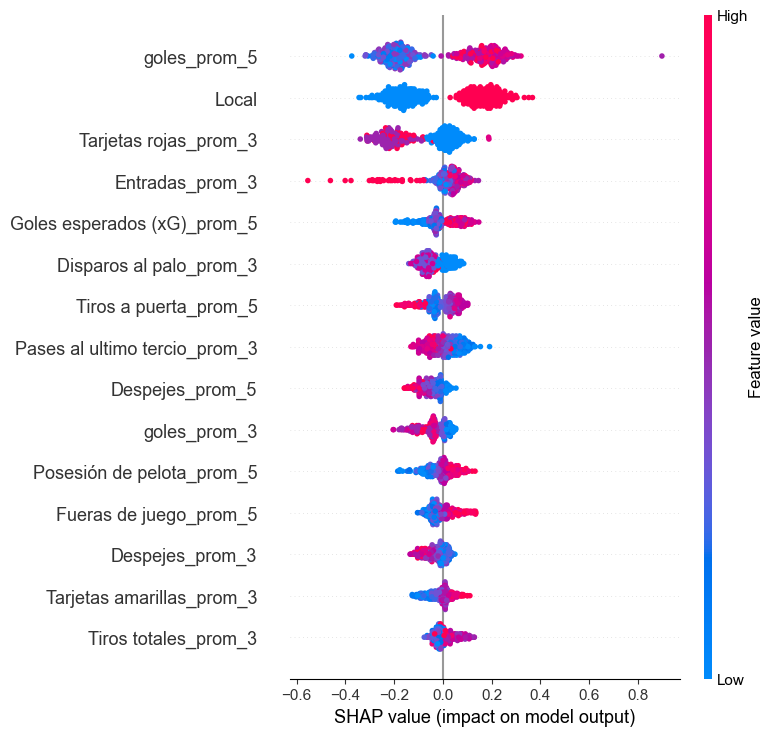

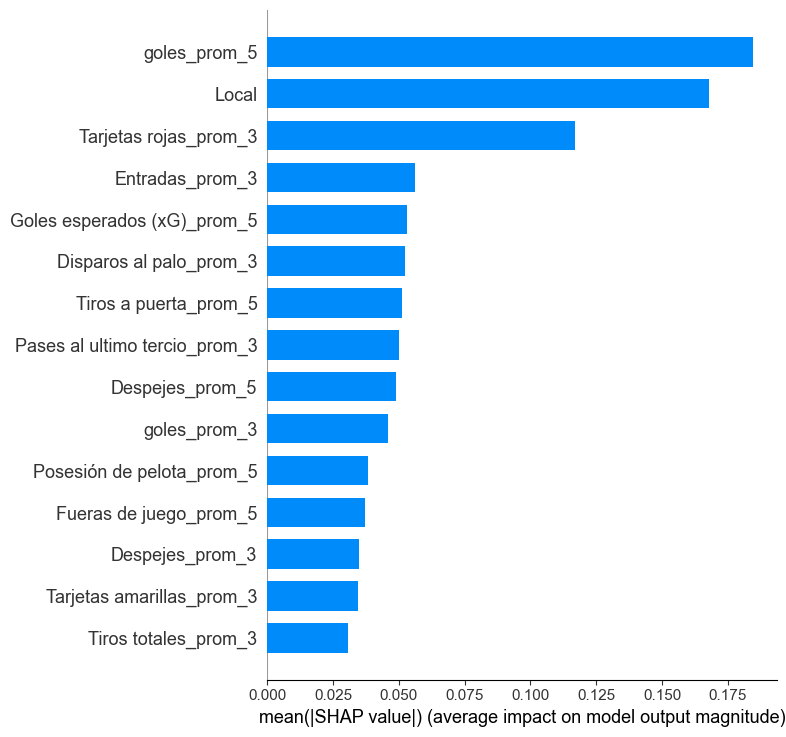


Top 15 features por |SHAP| promedio:
goles_prom_5                     0.184437
Local                            0.167704
Tarjetas rojas_prom_3            0.116793
Entradas_prom_3                  0.056055
Goles esperados (xG)_prom_5      0.053253
Disparos al palo_prom_3          0.052338
Tiros a puerta_prom_5            0.051321
Pases al ultimo tercio_prom_3    0.050207
Despejes_prom_5                  0.048905
goles_prom_3                     0.045839
Posesión de pelota_prom_5        0.038239
Fueras de juego_prom_5           0.037288
Despejes_prom_3                  0.035037
Tarjetas amarillas_prom_3        0.034492
Tiros totales_prom_3             0.030704


In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# INTERPRETABILIDAD DEL MODELO — Análisis SHAP
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("ANÁLISIS SHAP — Importancia y dirección de las features")
print("=" * 60)

explainer   = shap.TreeExplainer(xgb_final_model)
shap_values = explainer.shap_values(X_test)

# ── Summary plot (beeswarm) — impacto y dirección por observación ────────────
shap.summary_plot(shap_values, X_test, show=False, max_display=15)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# ── Bar plot — importancia media absoluta (ranking global) ───────────────────
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False, max_display=15)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# ── Ranking numérico de las 15 features más influyentes ──────────────────────
importancia_shap = np.abs(shap_values).mean(axis=0)
ranking = pd.Series(importancia_shap, index=features_final).sort_values(ascending=False)

print("\nTop 15 features por |SHAP| promedio:")
print(ranking.head(15).to_string())

In [14]:
import joblib
import pandas as pd

# ── Rutas de los modelos ───────────────────────────────────────────────────────
BASE = 'Hiperparametros_Finales'

archivos = {
    'XGBoost': {
        'Target_XG':           f'{BASE}/Goles_Esperadas/modelo_xgboost_xg.pkl',
        'Target_Tiros_Puerta': f'{BASE}/Tiros_Puerta/modelo_xgboost_tiros.pkl',
        'Target_Goles':        f'{BASE}/Goles/modelo_xgboost_liga1_goles.pkl',
    },
    'LightGBM': {
        'Target_XG':           f'{BASE}/Goles_Esperadas/modelo_lightgbm_xg.pkl',
        'Target_Tiros_Puerta': f'{BASE}/Tiros_Puerta/modelo_lightgbm_tiros.pkl',
        'Target_Goles':        f'{BASE}/Goles/modelo_lightgbm_liga1_goles.pkl',
    },
    'Random Forest': {
        'Target_XG':           f'{BASE}/Goles_Esperadas/modelo_randomforest_xg.pkl',
        'Target_Tiros_Puerta': f'{BASE}/Tiros_Puerta/modelo_randomforest_tiros.pkl',
        'Target_Goles':        f'{BASE}/Goles/modelo_randomforest_liga1_goles.pkl',
    },
    'Logistic Regression': {
        'Target_XG':           f'{BASE}/Goles_Esperadas/modelo_logistic_xg.pkl',
        'Target_Tiros_Puerta': f'{BASE}/Tiros_Puerta/modelo_logistic_tiros.pkl',
        'Target_Goles':        f'{BASE}/Goles/modelo_logistic_liga1_goles.pkl',
    },
}

# Parámetros a excluir del reporte (técnicos, no relevantes para la tabla)
excluir = {'random_state', 'n_jobs', 'verbosity', 'objective', 'use_label_encoder',
           'eval_metric', 'silent', 'nthread', 'max_iter', 'penalty', 'solver',
           'multi_class', 'warm_start', 'class_weight', 'dual', 'fit_intercept',
           'intercept_scaling', 'tol', 'verbose', 'oob_score', 'bootstrap',
           'n_features_in_', 'feature_names_in_'}

# Descripciones de hiperparámetros
descripciones = {
    'n_estimators':      'Número de árboles',
    'max_depth':         'Profundidad máxima del árbol',
    'learning_rate':     'Tasa de aprendizaje',
    'subsample':         'Fracción de muestras por árbol',
    'colsample_bytree':  'Fracción de features por árbol',
    'min_child_weight':  'Peso mínimo en nodo hoja',
    'gamma':             'Umbral mínimo de ganancia para dividir',
    'num_leaves':        'Número máximo de hojas por árbol',
    'min_child_samples': 'Muestras mínimas requeridas en hoja',
    'reg_alpha':         'Regularización L1',
    'reg_lambda':        'Regularización L2',
    'min_samples_split': 'Mínimo de muestras para dividir nodo',
    'min_samples_leaf':  'Mínimo de muestras en nodo hoja',
    'max_features':      'Features evaluadas por división',
    'C':                 'Inverso de la fuerza de regularización',
    'l1_ratio':          'Mezcla ElasticNet (0=L2, 1=L1)',
}

# ── Generar tabla por modelo ───────────────────────────────────────────────────
for modelo, rutas in archivos.items():
    print(f"\n{'='*70}")
    print(f"  {modelo}")
    print(f"{'='*70}")

    params_por_target = {}
    for target, ruta in rutas.items():
        m = joblib.load(ruta)
        p = {k: v for k, v in m.get_params().items()
             if k not in excluir and v is not None}
        params_por_target[target] = p

    # Unir todos los hiperparámetros encontrados
    todos_params = sorted(set().union(*[p.keys() for p in params_por_target.values()]))

    filas = []
    for param in todos_params:
        fila = {
            'Hiperparámetro': param,
            'Descripción':    descripciones.get(param, '—'),
            'Target_XG':           params_por_target['Target_XG'].get(param, '—'),
            'Target_Tiros_Puerta': params_por_target['Target_Tiros_Puerta'].get(param, '—'),
            'Target_Goles':        params_por_target['Target_Goles'].get(param, '—'),
        }
        filas.append(fila)

    df_tabla = pd.DataFrame(filas)

    # Redondear floats
    for col in ['Target_XG', 'Target_Tiros_Puerta', 'Target_Goles']:
        df_tabla[col] = df_tabla[col].apply(
            lambda x: round(x, 4) if isinstance(x, float) else x
        )

    print(df_tabla.to_string(index=False))



  XGBoost
    Hiperparámetro                            Descripción Target_XG Target_Tiros_Puerta Target_Goles
  colsample_bytree         Fracción de features por árbol    0.7595              0.8202       0.9182
enable_categorical                                      —     False               False        False
             gamma Umbral mínimo de ganancia para dividir    0.8987               0.871       0.8592
     learning_rate                    Tasa de aprendizaje    0.0149              0.0101       0.0134
         max_depth           Profundidad máxima del árbol         4                   6            6
  min_child_weight               Peso mínimo en nodo hoja         2                   4            3
           missing                                      —       NaN                 NaN          NaN
      n_estimators                      Número de árboles       156                 153          199
         subsample         Fracción de muestras por árbol     0.987             


  Target_XG (xG ≥ 1.5)
                 Accuracy  AUC-ROC  F1-Score  Precision  Recall
Modelo                                                         
XGBoost             65.64   0.6538    0.5338     0.5355  0.5321
LightGBM            65.17   0.6604    0.5505     0.5263  0.5769
Random Forest       62.56   0.6310    0.5380     0.4946  0.5897
Log. Regression     63.27   0.6655    0.5481     0.5027  0.6026

  Mejor Accuracy : XGBoost (65.64%)
  Mejor AUC-ROC  : Log. Regression (0.6655)
  Mejor F1-Score : LightGBM (0.5505)


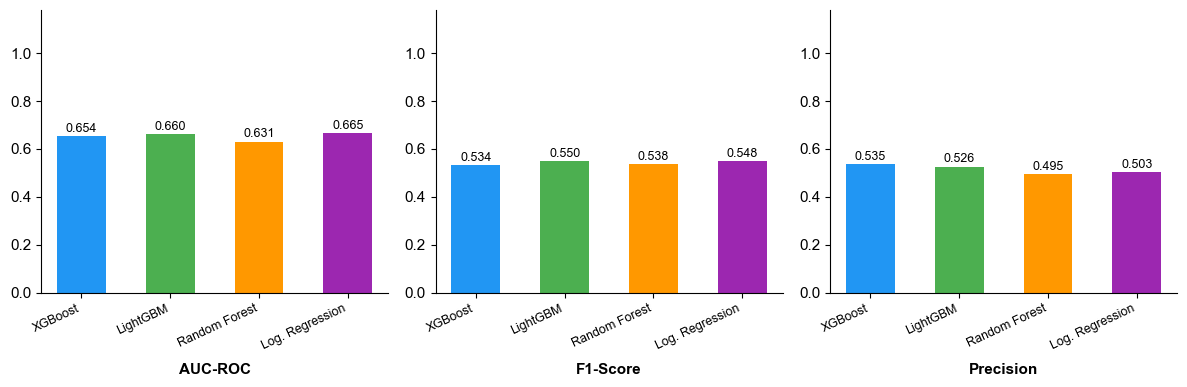

<Figure size 640x480 with 0 Axes>

✅ Gráfico guardado: comparacion_Target_XG_xG__1.5.png

  Target_Tiros_Puerta (Tiros ≥ 5)
                 Accuracy  AUC-ROC  F1-Score  Precision  Recall
Modelo                                                         
XGBoost             65.17   0.6303    0.5421     0.5800  0.5088
LightGBM            63.27   0.6212    0.5455     0.5471  0.5439
Random Forest       61.14   0.6249    0.5233     0.5202  0.5263
Log. Regression     61.61   0.6440    0.5345     0.5254  0.5439

  Mejor Accuracy : XGBoost (65.17%)
  Mejor AUC-ROC  : Log. Regression (0.644)
  Mejor F1-Score : LightGBM (0.5455)


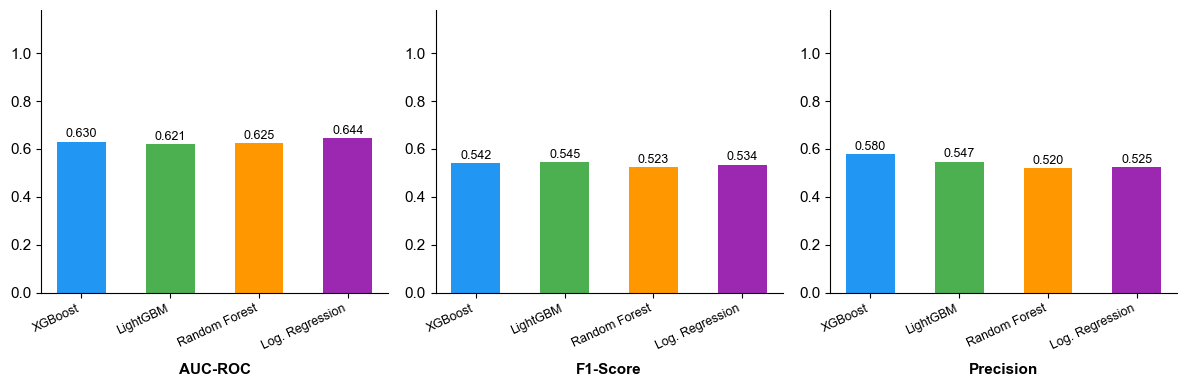

<Figure size 640x480 with 0 Axes>

✅ Gráfico guardado: comparacion_Target_Tiros_Puerta_Tiros__5.png

  Target_Goles (Goles ≥ 2)
                 Accuracy  AUC-ROC  F1-Score  Precision  Recall
Modelo                                                         
XGBoost             62.09   0.5688    0.3750     0.5393  0.2874
LightGBM            61.14   0.5625    0.3835     0.5152  0.3054
Random Forest       57.11   0.5694    0.4930     0.4632  0.5269
Log. Regression     63.03   0.6470    0.5357     0.5325  0.5389

  Mejor Accuracy : Log. Regression (63.03%)
  Mejor AUC-ROC  : Log. Regression (0.647)
  Mejor F1-Score : Log. Regression (0.5357)


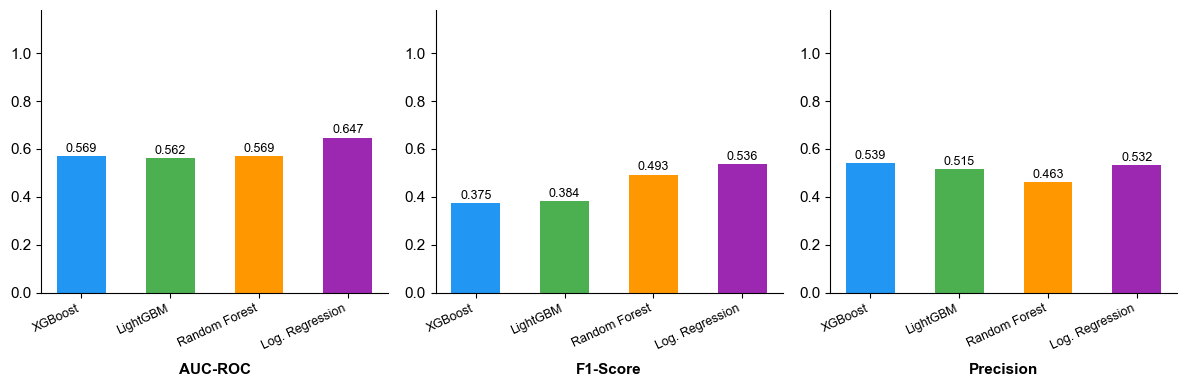

<Figure size 640x480 with 0 Axes>

✅ Gráfico guardado: comparacion_Target_Goles_Goles__2.png


In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE 6 — Comparación de 4 modelos para los 3 targets
# ══════════════════════════════════════════════════════════════════════════════
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score

BASE = 'Hiperparametros_Finales'

# ── Definición de targets ──────────────────────────────────────────────────────
targets_def = {
    'Target_XG\n(xG ≥ 1.5)': {
        'condicion':  df_modelado_completo['Goles esperados (xG)'] >= 1.5,
        'xgb':        f'{BASE}/Goles_Esperadas/modelo_xgboost_xg.pkl',
        'lgbm':       f'{BASE}/Goles_Esperadas/modelo_lightgbm_xg.pkl',
        'rf':         f'{BASE}/Goles_Esperadas/modelo_randomforest_xg.pkl',
        'lr':         f'{BASE}/Goles_Esperadas/modelo_logistic_xg.pkl',
        'scaler':     f'{BASE}/Goles_Esperadas/scaler_logistic_xg.pkl',
    },
    'Target_Tiros_Puerta\n(Tiros ≥ 5)': {
        'condicion':  df_modelado_completo['Tiros a puerta'] >= 5,
        'xgb':        f'{BASE}/Tiros_Puerta/modelo_xgboost_tiros.pkl',
        'lgbm':       f'{BASE}/Tiros_Puerta/modelo_lightgbm_tiros.pkl',
        'rf':         f'{BASE}/Tiros_Puerta/modelo_randomforest_tiros.pkl',
        'lr':         f'{BASE}/Tiros_Puerta/modelo_logistic_tiros.pkl',
        'scaler':     f'{BASE}/Tiros_Puerta/scaler_logistic_tiros.pkl',
    },
    'Target_Goles\n(Goles ≥ 2)': {
        'condicion':  df_modelado_completo['goles'] >= 2,
        'xgb':        f'{BASE}/Goles/modelo_xgboost_liga1_goles.pkl',
        'lgbm':       f'{BASE}/Goles/modelo_lightgbm_liga1_goles.pkl',
        'rf':         f'{BASE}/Goles/modelo_randomforest_liga1_goles.pkl',
        'lr':         f'{BASE}/Goles/modelo_logistic_liga1_goles.pkl',
        'scaler':     f'{BASE}/Goles/scaler_logistic_liga1_goles.pkl',
    },
}

metricas_cols = ['Accuracy', 'AUC-ROC', 'F1-Score', 'Precision', 'Recall']
colores_modelos = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
nombres_modelos = ['XGBoost', 'LightGBM', 'Random Forest', 'Log. Regression']

resultados_globales = {}

for nombre_target, cfg in targets_def.items():

    # y_test para este target
    y_target = cfg['condicion'].astype(int)
    test_mask = df_modelado_completo['Fecha'] > df_modelado_completo['Fecha'].quantile(0.8)
    y_t = y_target[test_mask].values

    # Cargar modelos y scaler
    m_xgb  = joblib.load(cfg['xgb'])
    m_lgbm = joblib.load(cfg['lgbm'])
    m_rf   = joblib.load(cfg['rf'])
    m_lr   = joblib.load(cfg['lr'])
    scaler = joblib.load(cfg['scaler'])

    X_t        = X_test  # mismo para los 3 targets
    X_t_scaled = scaler.transform(X_t)

    preds = {
        'XGBoost':        (m_xgb.predict(X_t),        m_xgb.predict_proba(X_t)[:,1]),
        'LightGBM':       (m_lgbm.predict(X_t),       m_lgbm.predict_proba(X_t)[:,1]),
        'Random Forest':  (m_rf.predict(X_t),         m_rf.predict_proba(X_t)[:,1]),
        'Log. Regression':(m_lr.predict(X_t_scaled),  m_lr.predict_proba(X_t_scaled)[:,1]),
    }

    filas = []
    for modelo, (pred, prob) in preds.items():
        filas.append({
            'Modelo':    modelo,
            'Accuracy':  round(accuracy_score(y_t, pred) * 100, 2),
            'AUC-ROC':   round(roc_auc_score(y_t, prob), 4),
            'F1-Score':  round(f1_score(y_t, pred), 4),
            'Precision': round(precision_score(y_t, pred), 4),
            'Recall':    round(recall_score(y_t, pred), 4),
        })

    df_comp = pd.DataFrame(filas).set_index('Modelo')
    resultados_globales[nombre_target] = df_comp

    # ── Tabla en consola ───────────────────────────────────────────────────────
    titulo = nombre_target.replace('\n', ' ')
    print(f"\n{'='*70}")
    print(f"  {titulo}")
    print(f"{'='*70}")
    print(df_comp.to_string())
    print(f"\n  Mejor Accuracy : {df_comp['Accuracy'].idxmax()} ({df_comp['Accuracy'].max()}%)")
    print(f"  Mejor AUC-ROC  : {df_comp['AUC-ROC'].idxmax()} ({df_comp['AUC-ROC'].max()})")
    print(f"  Mejor F1-Score : {df_comp['F1-Score'].idxmax()} ({df_comp['F1-Score'].max()})")

     # ── Gráfico APA 7 — sin título en imagen ──────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    for ax, metrica in zip(axes, ['AUC-ROC', 'F1-Score', 'Precision']):
        valores = df_comp[metrica].values
        barras  = ax.bar(range(4), valores, color=colores_modelos, width=0.55)
        ax.set_xlabel(metrica, fontsize=11, fontweight='bold', labelpad=8)
        ax.set_ylim(0, 1.18)
        ax.set_xticks(range(4))
        ax.set_xticklabels(nombres_modelos, rotation=25, ha='right', fontsize=9)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        for bar, val in zip(barras, valores):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.005,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig(f'comparacion_{nombre_archivo}.png', dpi=300,
                bbox_inches='tight', facecolor='white')
    plt.show()



    plt.tight_layout()
    nombre_archivo = titulo.replace('\n','_').replace(' ','_').replace('≥','').replace('(','').replace(')','')
    plt.savefig(f'comparacion_{nombre_archivo}.png', dpi=200,
                bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"✅ Gráfico guardado: comparacion_{nombre_archivo}.png")


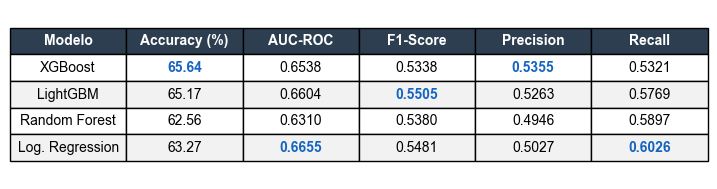

✅ Tabla guardada: tabla_Target_XG_xG_gte_15.png


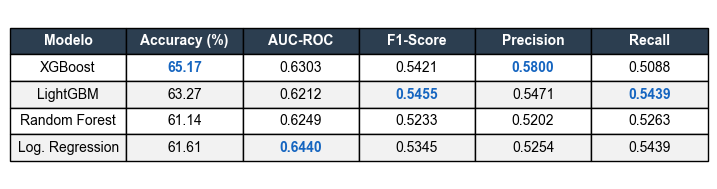

✅ Tabla guardada: tabla_Target_Tiros_Puerta_Tiros_gte_5.png


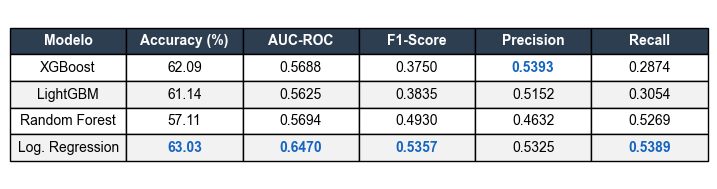

✅ Tabla guardada: tabla_Target_Goles_Goles_gte_2.png


In [18]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Calibri', 'DejaVu Sans'],
})

for nombre_target, df_comp in resultados_globales.items():
    titulo = nombre_target.replace('\n', ' ')

    fig, ax = plt.subplots(figsize=(9, 2.2))
    ax.axis('off')

    # Datos de la tabla
    columnas = ['Modelo', 'Accuracy (%)', 'AUC-ROC', 'F1-Score', 'Precision', 'Recall']
    filas = []
    for modelo, row in df_comp.iterrows():
        filas.append([
            modelo,
            f"{row['Accuracy']:.2f}",
            f"{row['AUC-ROC']:.4f}",
            f"{row['F1-Score']:.4f}",
            f"{row['Precision']:.4f}",
            f"{row['Recall']:.4f}",
        ])

    tabla = ax.table(
        cellText=filas,
        colLabels=columnas,
        cellLoc='center',
        loc='center',
    )

    tabla.auto_set_font_size(False)
    tabla.set_fontsize(10)
    tabla.scale(1, 1.6)

    # Estilo encabezado
    for j in range(len(columnas)):
        tabla[0, j].set_facecolor('#2C3E50')
        tabla[0, j].set_text_props(color='white', fontweight='bold')

    # Filas alternadas
    for i in range(1, len(filas) + 1):
        color = '#F2F2F2' if i % 2 == 0 else 'white'
        for j in range(len(columnas)):
            tabla[i, j].set_facecolor(color)

    # Resaltar mejor valor por métrica (columnas 1-5)
    for j, col in enumerate(['Accuracy', 'AUC-ROC', 'F1-Score', 'Precision', 'Recall']):
        idx_max = df_comp[col].idxmax()
        i_max   = list(df_comp.index).index(idx_max) + 1
        tabla[i_max, j + 1].set_text_props(fontweight='bold', color='#1565C0')

    nombre_archivo = titulo.replace(' ', '_').replace('(', '').replace(')', '').replace('≥', 'gte').replace('.', '')
    plt.savefig(f'tabla_{nombre_archivo}.png', dpi=200,
                bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"✅ Tabla guardada: tabla_{nombre_archivo}.png")



  SHAP — Target_XG


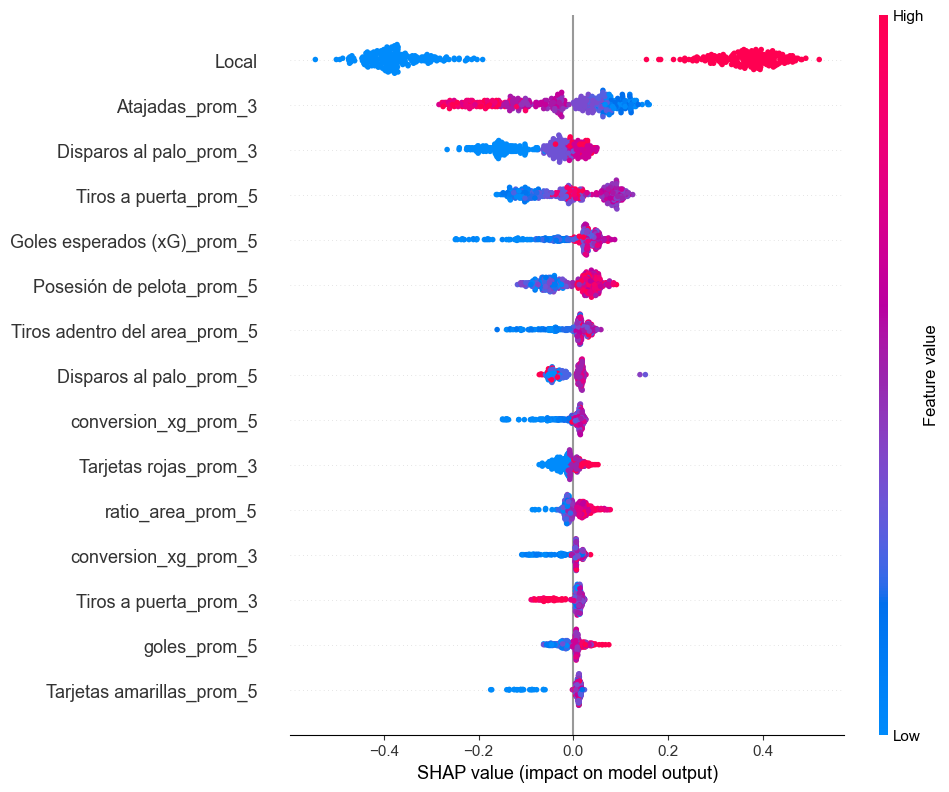

✅ Beeswarm guardado: shap_beeswarm_XG.png


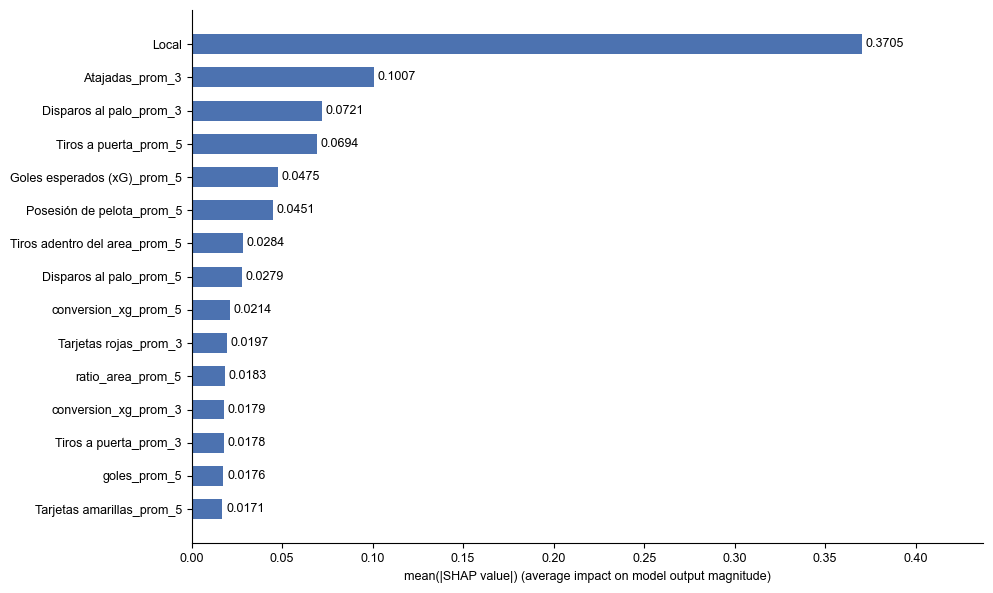

✅ Bar plot guardado: shap_bar_XG.png

  SHAP — Target_Tiros_Puerta


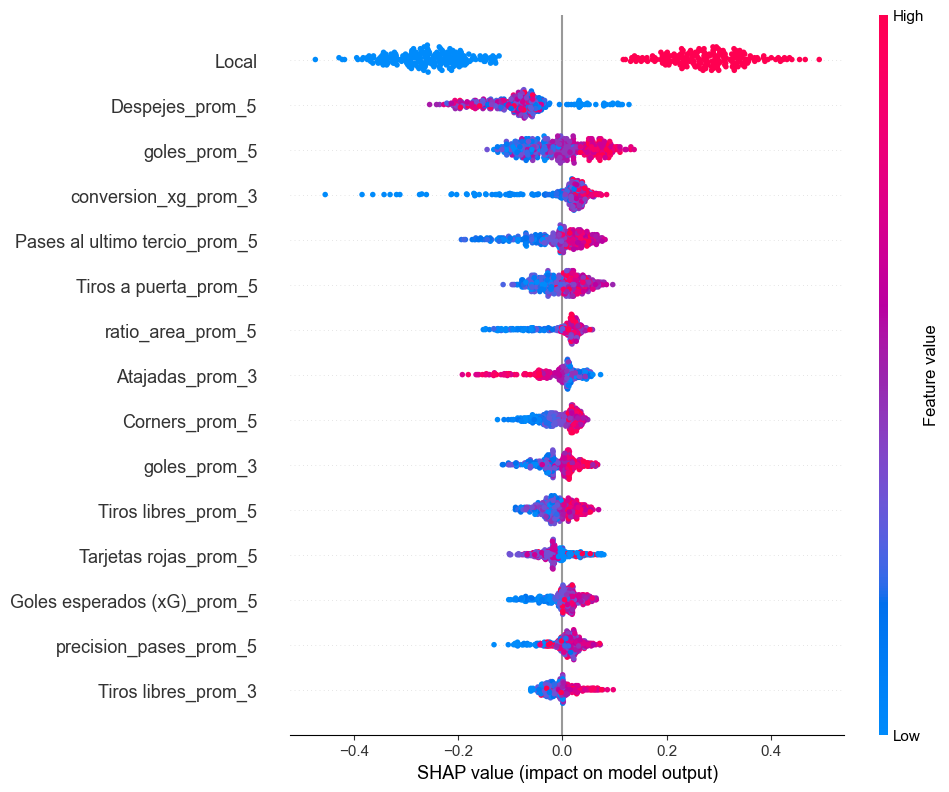

✅ Beeswarm guardado: shap_beeswarm_Tiros_Puerta.png


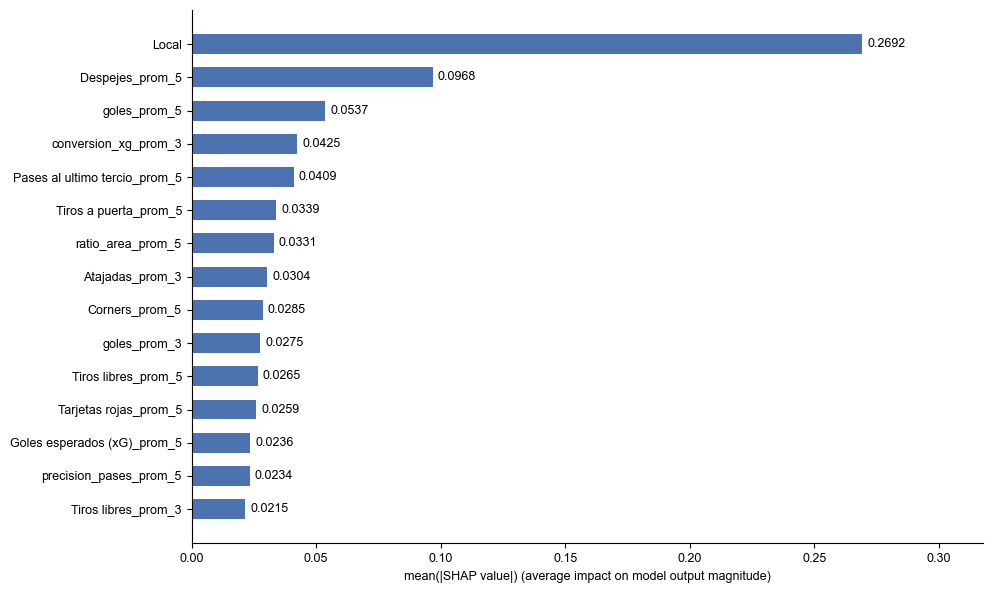

✅ Bar plot guardado: shap_bar_Tiros_Puerta.png

  SHAP — Target_Goles


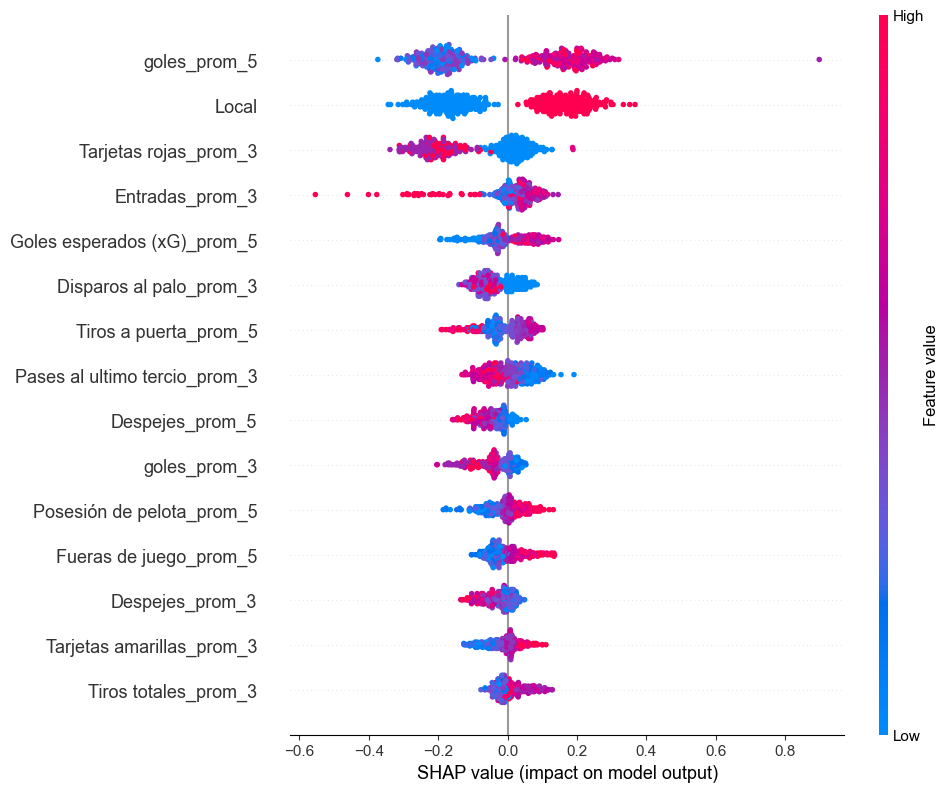

✅ Beeswarm guardado: shap_beeswarm_Goles.png


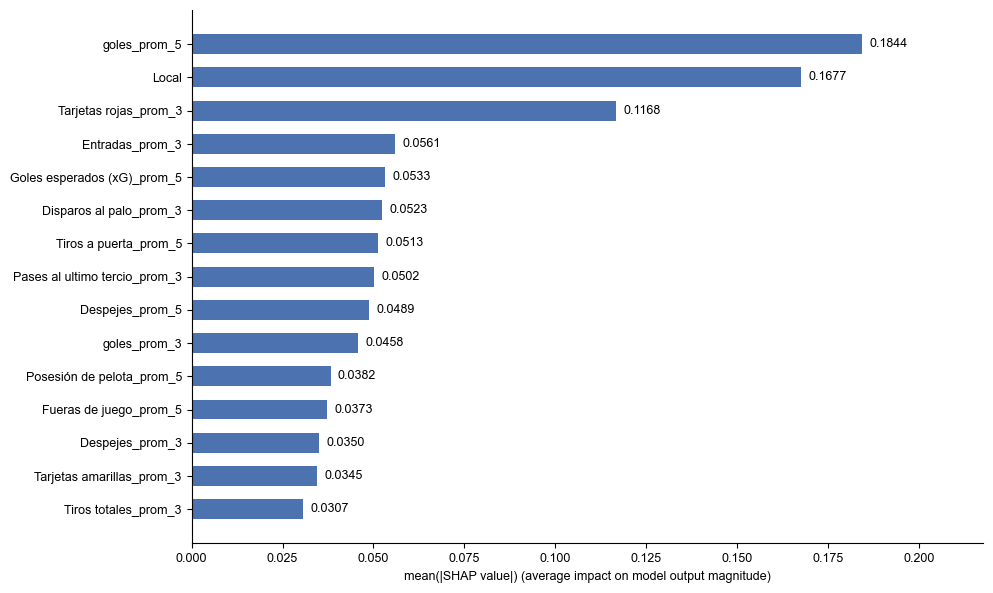

✅ Bar plot guardado: shap_bar_Goles.png


In [26]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE 7 — Análisis SHAP para los 3 targets (XGBoost)
# ══════════════════════════════════════════════════════════════════════════════
import shap
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Calibri', 'DejaVu Sans'],
    'font.size': 9,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

BASE = 'Hiperparametros_Finales'

targets_shap = {
    'XG':           f'{BASE}/Goles_Esperadas/modelo_xgboost_xg.pkl',
    'Tiros_Puerta': f'{BASE}/Tiros_Puerta/modelo_xgboost_tiros.pkl',
    'Goles':        f'{BASE}/Goles/modelo_xgboost_liga1_goles.pkl',
}

for nombre, ruta_pkl in targets_shap.items():

    print(f"\n{'='*60}")
    print(f"  SHAP — Target_{nombre}")
    print(f"{'='*60}")

    # Cargar modelo
    modelo = joblib.load(ruta_pkl)

    # SHAP sobre X_test (datos reales, no sintéticos SMOTE)
    explainer   = shap.TreeExplainer(modelo)
    shap_values = explainer.shap_values(X_test)

    # ── Beeswarm plot ──────────────────────────────────────────────────────────
    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        shap_values, X_test,
        show=False,
        max_display=15,
        plot_size=None
    )
    plt.tight_layout()
    plt.savefig(f'shap_beeswarm_{nombre}.png', dpi=300,
                bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"✅ Beeswarm guardado: shap_beeswarm_{nombre}.png")

    # ── Bar plot con valores ───────────────────────────────────────────────────
    top15 = pd.Series(
        np.abs(shap_values).mean(axis=0),
        index=features_final
    ).sort_values(ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(10, 6))
    barras = ax.barh(range(15), top15.values[::-1], color='#4C72B0', height=0.6)
    ax.set_yticks(range(15))
    ax.set_yticklabels(top15.index[::-1], fontsize=9)
    ax.set_xlabel('mean(|SHAP value|) (average impact on model output magnitude)', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Valor al lado de cada barra
    for i, (bar, val) in enumerate(zip(barras, top15.values[::-1])):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

    ax.set_xlim(0, top15.values.max() * 1.18)
    plt.tight_layout()
    plt.savefig(f'shap_bar_{nombre}.png', dpi=300,
                bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"✅ Bar plot guardado: shap_bar_{nombre}.png")


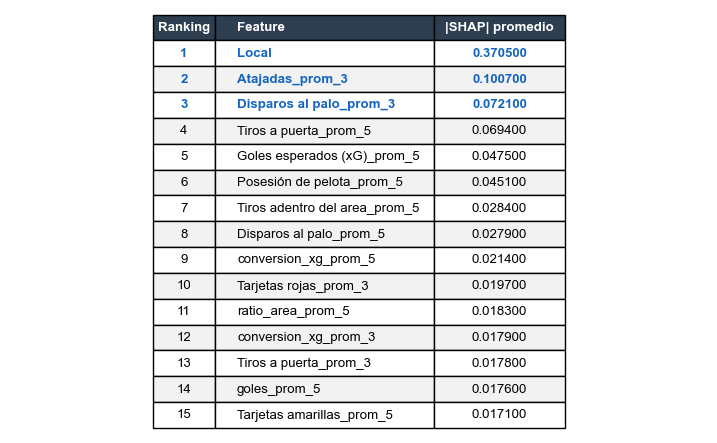

✅ Tabla guardada: shap_tabla_Target_XG_xG_gte_15.png


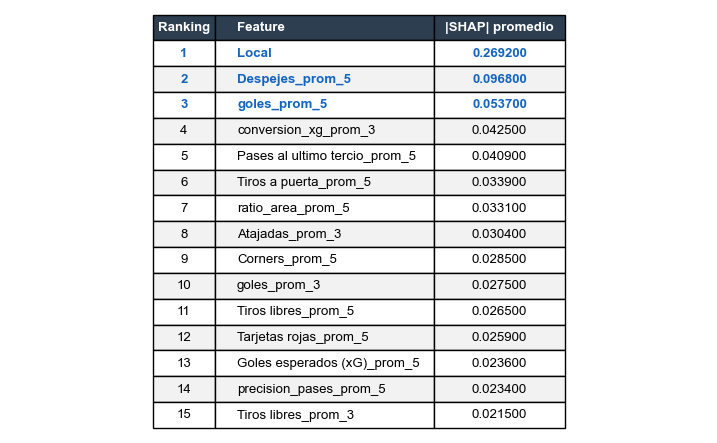

✅ Tabla guardada: shap_tabla_Target_Tiros_Puerta_Tiros_gte_5.png


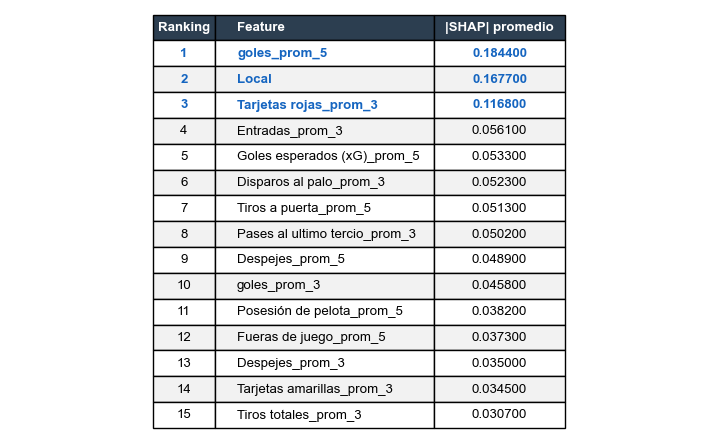

✅ Tabla guardada: shap_tabla_Target_Goles_Goles_gte_2.png


In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE 7B — Tablas SHAP como imagen (mismo formato que comparación modelos)
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib as mpl
import joblib, shap, numpy as np, pandas as pd

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Calibri', 'DejaVu Sans'],
})

BASE = 'Hiperparametros_Finales'

targets_shap = {
    'Target_XG (xG ≥ 1.5)':              f'{BASE}/Goles_Esperadas/modelo_xgboost_xg.pkl',
    'Target_Tiros_Puerta (Tiros ≥ 5)':   f'{BASE}/Tiros_Puerta/modelo_xgboost_tiros.pkl',
    'Target_Goles (Goles ≥ 2)':          f'{BASE}/Goles/modelo_xgboost_liga1_goles.pkl',
}

for nombre_target, ruta_pkl in targets_shap.items():

    modelo      = joblib.load(ruta_pkl)
    explainer   = shap.TreeExplainer(modelo)
    shap_values = explainer.shap_values(X_test)

    importancia = pd.Series(
        np.abs(shap_values).mean(axis=0),
        index=features_final
    ).sort_values(ascending=False).head(15).reset_index()
    importancia.columns = ['Feature', '|SHAP| promedio']
    importancia.insert(0, 'Ranking', range(1, 16))
    importancia['|SHAP| promedio'] = importancia['|SHAP| promedio'].round(4)

    # ── Generar tabla imagen ───────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.axis('off')

    columnas = ['Ranking', 'Feature', '|SHAP| promedio']
    filas = [
    [row['Ranking'], row['Feature'], f"{row['|SHAP| promedio']:.6f}"]
    for _, row in importancia.iterrows()
]

    tabla = ax.table(
        cellText=filas,
        colLabels=columnas,
        cellLoc='center',
        loc='center',
    )

    tabla.auto_set_font_size(False)
    tabla.set_fontsize(9.5)
    tabla.scale(1, 1.55)

    # Alineación izquierda para Feature
    for i in range(1, 16):
        tabla[i, 1].set_text_props(ha='left')
    tabla[0, 1].set_text_props(ha='left')

    # Ancho de columnas
    tabla.auto_set_column_width([0, 1, 2])

    # Estilo encabezado
    for j in range(3):
        tabla[0, j].set_facecolor('#2C3E50')
        tabla[0, j].set_text_props(color='white', fontweight='bold')

    # Filas alternadas
    for i in range(1, 16):
        color = '#F2F2F2' if i % 2 == 0 else 'white'
        for j in range(3):
            tabla[i, j].set_facecolor(color)

    # Resaltar top 3 en negrita azul
    for i in range(1, 4):
        for j in range(3):
            tabla[i, j].set_text_props(fontweight='bold', color='#1565C0')

    nombre_archivo = nombre_target.replace(' ', '_').replace('(', '').replace(')', '').replace('≥', 'gte').replace('.', '')
    plt.savefig(f'shap_tabla_{nombre_archivo}.png', dpi=200,
                bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"✅ Tabla guardada: shap_tabla_{nombre_archivo}.png")


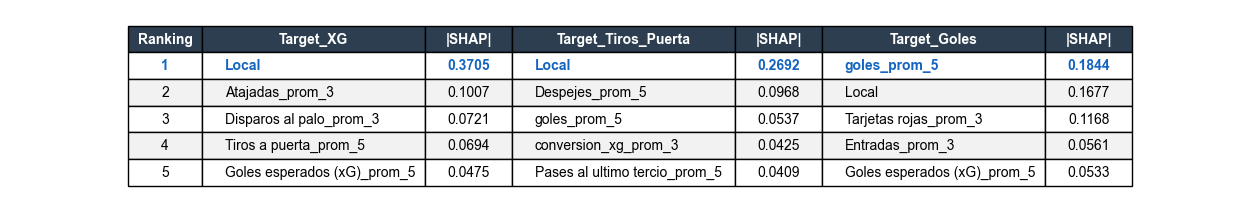

✅ Tabla guardada: shap_comparativa_top5.png


In [44]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE 7C — Tabla comparativa SHAP top 5 entre los 3 targets
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Calibri', 'DejaVu Sans'],
})

# Top 5 de cada target (feature + valor)
top_xg = [
    ('Local',                      0.3705),
    ('Atajadas_prom_3',            0.1007),
    ('Disparos al palo_prom_3',    0.0721),
    ('Tiros a puerta_prom_5',      0.0694),
    ('Goles esperados (xG)_prom_5',0.0475),
]
top_tiros = [
    ('Local',                      0.2692),
    ('Despejes_prom_5',            0.0968),
    ('goles_prom_5',               0.0537),
    ('conversion_xg_prom_3',       0.0425),
    ('Pases al ultimo tercio_prom_5', 0.0409),
]
top_goles = [
    ('goles_prom_5',               0.1844),
    ('Local',                      0.1677),
    ('Tarjetas rojas_prom_3',      0.1168),
    ('Entradas_prom_3',            0.0561),
    ('Goles esperados (xG)_prom_5',0.0533),
]

columnas = ['Ranking',
            'Target_XG', '|SHAP|',
            'Target_Tiros_Puerta', '|SHAP|',
            'Target_Goles', '|SHAP|']

filas = []
for i in range(5):
    filas.append([
        i + 1,
        top_xg[i][0],    f'{top_xg[i][1]:.4f}',
        top_tiros[i][0], f'{top_tiros[i][1]:.4f}',
        top_goles[i][0], f'{top_goles[i][1]:.4f}',
    ])

fig, ax = plt.subplots(figsize=(16, 2.5))
ax.axis('off')

tabla = ax.table(
    cellText=filas,
    colLabels=columnas,
    cellLoc='center',
    loc='center',
)

tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1, 1.6)

# Alineación izquierda para features
for i in range(1, 6):
    tabla[i, 1].set_text_props(ha='left')
    tabla[i, 3].set_text_props(ha='left')
    tabla[i, 5].set_text_props(ha='left')

# Ancho de columnas
col_widths = {0: 0.06, 1: 0.18, 2: 0.07, 3: 0.18, 4: 0.07, 5: 0.18, 6: 0.07}
for col, width in col_widths.items():
    for row in range(6):
        tabla[row, col].set_width(width)


# Encabezado
for j in range(7):
    tabla[0, j].set_facecolor('#2C3E50')
    tabla[0, j].set_text_props(color='white', fontweight='bold')

# Filas alternadas
for i in range(1, 6):
    color = '#F2F2F2' if i % 2 == 0 else 'white'
    for j in range(7):
        tabla[i, j].set_facecolor(color)

# Resaltar fila 1 en negrita azul
for j in range(7):
    tabla[1, j].set_text_props(fontweight='bold', color='#1565C0')

plt.savefig('shap_comparativa_top5.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Tabla guardada: shap_comparativa_top5.png")
